# Step 120 dense30 试验复盘

**TL;DR：** 老板原版评分从 Step 100 的 `0.443750` 升到 Step 120 的 `0.563745`，但提升主要来自完成率和过程覆盖；数值正确由 3/20 降到 2/20。dense30 自身几乎不变，因此应先扩大密封评测、增强组内正确性信号，而不是直接继续堆训练步数。

本 notebook 只读取仓库中的聚合汇总，不包含服务器路径、原始轨迹、模型或数据库。

In [1]:
from pathlib import Path
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.style.use("seaborn-v0_8-whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
summary_path = ROOT / "docs" / "step120_dense_trial_20260810_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8"))
summary["analysis"], summary["generated_at"]

('step120_dense_correctness_trial', '2026-08-10T16:30:00+08:00')

## 1. 数据质量与可比性

比较前先验证三版是否真的在同一批题、同一输入、同一 ground truth 上评测，并检查奖励公式复算与 verifier error。

In [2]:
integrity = summary["validation_integrity"]
quality = pd.DataFrame({
    "检查": ["task 集合一致", "共同任务数", "GTS 逐题一致", "prompt 逐题一致", "verifier error 总数"],
    "结果": [
        integrity["task_sets_identical"],
        integrity["common_task_count"],
        integrity["gts_identical_count"],
        integrity["prompt_identical_count"],
        sum(integrity["verifier_error_counts"].values()),
    ],
})
quality

,检查,结果
0,task 集合一致,True
1,共同任务数,20
2,GTS 逐题一致,20
3,prompt 逐题一致,20
4,verifier error 总数,0


## 2. 老板原版评分

老板总奖励、结果分和过程分来自原版 `reward_judge.py`。Step 120 的总分点估计提升 0.119995，但 20 道题的配对置信区间仍跨 0。

In [3]:
c100_120 = summary["boss_exact"]["step100_vs_step120"]
c120_200 = summary["boss_exact"]["step120_vs_step200"]
boss = pd.DataFrame([
    {"checkpoint": label, "老板总奖励": row["reward_total_mean"], "结果分": row["result_score_mean"], "过程分": row["process_score_mean"]}
    for label, row in [
        ("Step 100", c100_120["step100"]),
        ("Step 120", c100_120["step120"]),
        ("Step 200", c120_200["step200"]),
    ]
]).set_index("checkpoint")
boss

,老板总奖励,结果分,过程分
checkpoint,,,
Step 100,0.443750,0.40,0.76500
Step 120,0.563745,0.45,0.84000
Step 200,0.399685,0.35,0.72375


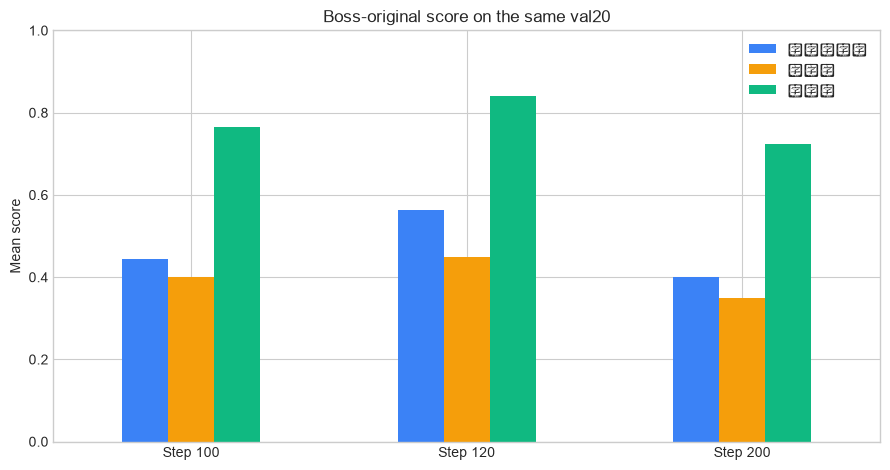

In [4]:
ax = boss.plot(kind="bar", figsize=(9, 4.8), ylim=(0, 1), rot=0, color=["#3B82F6", "#F59E0B", "#10B981"])
ax.set_title("Boss-original score on the same val20")
ax.set_ylabel("Mean score")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [5]:
b100, b120 = c100_120["step100"], c100_120["step120"]
behavior = pd.DataFrame({
    "Step 100": [b100["complete_count"], b100["correct_numeric_count"], b100["tables_hit_count"]],
    "Step 120": [b120["complete_count"], b120["correct_numeric_count"], b120["tables_hit_count"]],
}, index=["完整收尾", "数值正确", "必需表命中"])
paired_boss = c100_120["paired_reward"]
display(behavior)
pd.Series({
    "mean_delta": c100_120["numeric_deltas"]["reward_total_mean"]["delta"],
    "bootstrap_ci_low": paired_boss["mean_delta_bootstrap_95pct_ci"][0],
    "bootstrap_ci_high": paired_boss["mean_delta_bootstrap_95pct_ci"][1],
    "wins": paired_boss["wins"], "losses": paired_boss["losses"], "ties": paired_boss["ties"],
    "exact_sign_p": paired_boss["exact_sign_test_p"],
})

,Step 100,Step 120
完整收尾,13,16
数值正确,3,2
必需表命中,15,18


mean_delta            0.119995
bootstrap_ci_low     -0.019375
bootstrap_ci_high     0.265610
wins                  7.000000
losses                3.000000
ties                 10.000000
exact_sign_p          0.343750
dtype: float64

## 3. dense30 同口径复算

三版都用 Step 120 的 dense30 公式重新计算，避免拿旧 reward 和新 reward 直接比较。这里是判断奖励改造是否在自身目标上起效的关键证据。

In [6]:
dense = pd.DataFrame([
    {
        "checkpoint": f"Step {step}",
        "dense30": summary["validation"][f"step{step}"]["means"]["dense30_score"],
        "dense correctness": summary["validation"][f"step{step}"]["means"]["dense_final_answer_correctness"],
        "base score": summary["validation"][f"step{step}"]["means"]["base_score"],
    }
    for step in (100, 120, 200)
]).set_index("checkpoint")
dense

,dense30,dense correctness,base score
checkpoint,,,
Step 100,0.324059,0.131231,0.406700
Step 120,0.324087,0.142873,0.401750
Step 200,0.255862,0.093432,0.325475


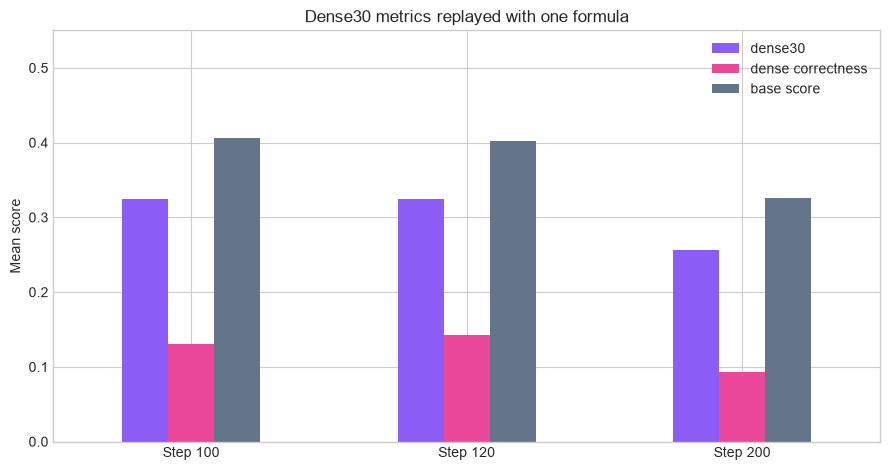

In [7]:
ax = dense.plot(kind="bar", figsize=(9, 4.8), ylim=(0, 0.55), rot=0, color=["#8B5CF6", "#EC4899", "#64748B"])
ax.set_title("Dense30 metrics replayed with one formula")
ax.set_ylabel("Mean score")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [8]:
paired = summary["paired_validation"]["step100_vs_step120"]
pd.DataFrame([
    {
        "metric": key,
        "delta": paired[key]["mean_delta"],
        "ci_low": paired[key]["paired_bootstrap_95pct_ci"][0],
        "ci_high": paired[key]["paired_bootstrap_95pct_ci"][1],
        "wins": paired[key]["wins"], "losses": paired[key]["losses"], "ties": paired[key]["ties"],
    }
    for key in ("dense30_score", "dense_final_answer_correctness", "base_score", "boss_reward")
]).set_index("metric")

,delta,ci_low,ci_high,wins,losses,ties
metric,,,,,,
dense30_score,0.000028,-0.059469,0.060653,7,10,3
dense_final_answer_correctness,0.011642,-0.040999,0.067546,8,8,4
base_score,-0.004950,-0.079450,0.071350,8,6,6
boss_reward,0.001500,-0.096000,0.101500,8,6,6


## 4. 训练曲线与耗时

日志有 19 个在线 score 汇总（Step 102–120），Step 101 汇总行缺失；另有 20 个 stage 耗时记录。在线分数每步样本不同，因此只看波动，不当作固定集泛化曲线。

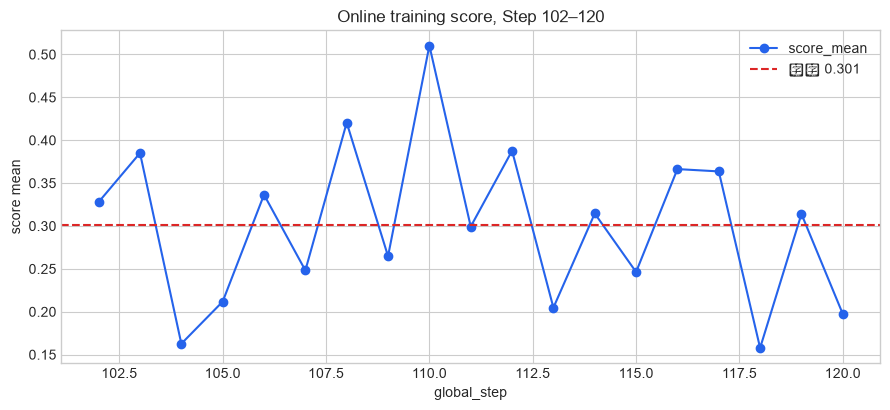

In [9]:
run = summary["training_run"]
curve = pd.DataFrame(run["score_metric_rows"])
ax = curve.plot(x="global_step", y="score_mean", marker="o", figsize=(9, 4.2), legend=False, color="#2563EB")
ax.axhline(run["score_mean"], color="#DC2626", linestyle="--", label=f'均值 {run["score_mean"]:.3f}')
ax.set_title("Online training score, Step 102–120")
ax.set_ylabel("score mean")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
pd.DataFrame([
    {"阶段": "单步平均", "秒": run["mean_step_s"], "分钟": run["mean_step_s"] / 60},
    {"阶段": "最终验证", "秒": run["validation_time_s"], "分钟": run["validation_time_s"] / 60},
    {"阶段": "保存 checkpoint", "秒": run["checkpoint_save_time_s"], "分钟": run["checkpoint_save_time_s"] / 60},
]).round(2)

,阶段,秒,分钟
0,单步平均,611.66,10.19
1,最终验证,4054.63,67.58
2,保存 checkpoint,89.00,1.48


## 5. 结论与行动建议

1. Step 120 是当前更值得保留的候选：老板总分和过程完成度优于 Step 100/200。
2. 不能宣称正确性提升：数值正确 3/20→2/20，dense30 几乎不变，关键区间均跨 0。
3. 下一步先做 80–100 道密封集，并同时报告老板总分、dense 正确性和二值正确率。
4. 再训练时先提高 mixed-correct group 比例，并从同一 checkpoint 与 optimizer 状态做 20–30 步单因素 A/B。
5. 运行效率方面，结束阶段瓶颈是 67.6 分钟最终验证；保存 checkpoint 只有约 89 秒。

### 局限

- 固定集只有 20 题，且已多次查看，存在评测过拟合风险。
- 老板评分器是代理指标，不等于业务专家人工正确性。
- 跨 checkpoint 观察不能把所有差异因果归于 dense30 单个奖励改动。